# 01 — Data Exploration

## **Setup & Data Loading**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from wordcloud import WordCloud

In [3]:
train = pd.read_csv('../data/splits/train.csv')
val   = pd.read_csv('../data/splits/val.csv')
test  = pd.read_csv('../data/splits/test.csv')

## **EDA**

In [18]:
print("Dataset Dimensions:")
print(f"Train: {train.shape}")
print(f"Val:   {val.shape}")
print(f"Test:  {test.shape}\n")
print("Dataset Splits:")
print(f"Train: {len(train):,} sentences  ({train['label'].mean():.1%} ADE)")
print(f"Val:   {len(val):,}  sentences  ({val['label'].mean():.1%} ADE)")
print(f"Test:  {len(test):,}  sentences  ({test['label'].mean():.1%} ADE)\n")

Dataset Dimensions:
Train: (16461, 3)
Val:   (3527, 2)
Test:  (3528, 2)

Dataset Splits:
Train: 16,461 sentences  (29.0% ADE)
Val:   3,527  sentences  (29.0% ADE)
Test:  3,528  sentences  (29.0% ADE)



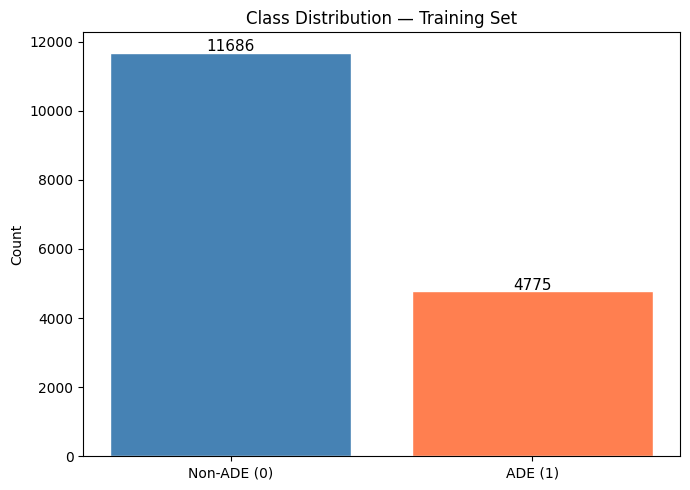

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = train['label'].value_counts()
ax.bar(['Non-ADE (0)', 'ADE (1)'], counts.values, 
       color=['steelblue', 'coral'], edgecolor='white')
ax.set_title('Class Distribution — Training Set')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/class_distribution.png', dpi=150)
plt.show()

## **Distribution of Sentences by Class**
ADE sentences are on average 2.9 words longer than non-ADE sentences,
consistent with the annotation requirement that ADE sentences must 
explicitly contain drug, adverse effect, and causal link within 
a single sentence.

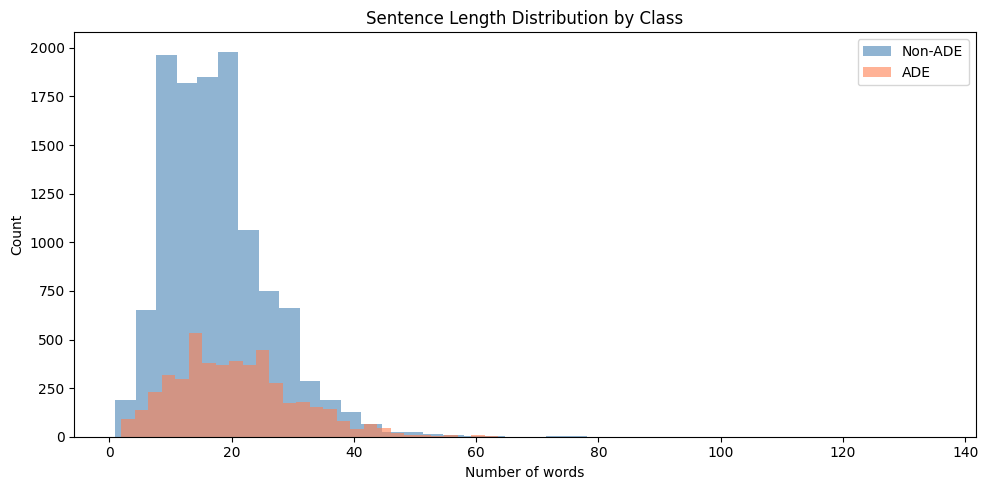

Non-ADE avg length: 17.7 words
ADE avg length:     20.6 words


In [6]:
train['length'] = train['text'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train[train['label']==0]['length'], bins=40, alpha=0.6, 
        label='Non-ADE', color='steelblue')
ax.hist(train[train['label']==1]['length'], bins=40, alpha=0.6, 
        label='ADE', color='coral')
ax.set_title('Sentence Length Distribution by Class')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/sentence_lengths.png', dpi=150)
plt.show()

print(f"Non-ADE avg length: {train[train['label']==0]['length'].mean():.1f} words")
print(f"ADE avg length:     {train[train['label']==1]['length'].mean():.1f} words")

## **Wordcloud Analysis**
Both classes share dominant vocabulary such as "patient", "treatment", "drug", and "report" reflecting the medical case report writing style of the corpus. These high frequency words carry no discriminative power and TF-IDF will correctly suppress them through low IDF scores since they appear across nearly every sentence in the dataset.

What separates the two classes is visible in the Label 1 cloud where causal and severity language dominates: "developed", "induced", "following", "severe", "acute". These terms are rarer across the corpus and TF-IDF will assign them high weights toward the positive class. However words like "induced" appearing without an actual causal drug-adverse relationship will still trigger a positive prediction since TF-IDF cannot distinguish context. That is where BioBERT's contextual embeddings are expected to provide an advantage.

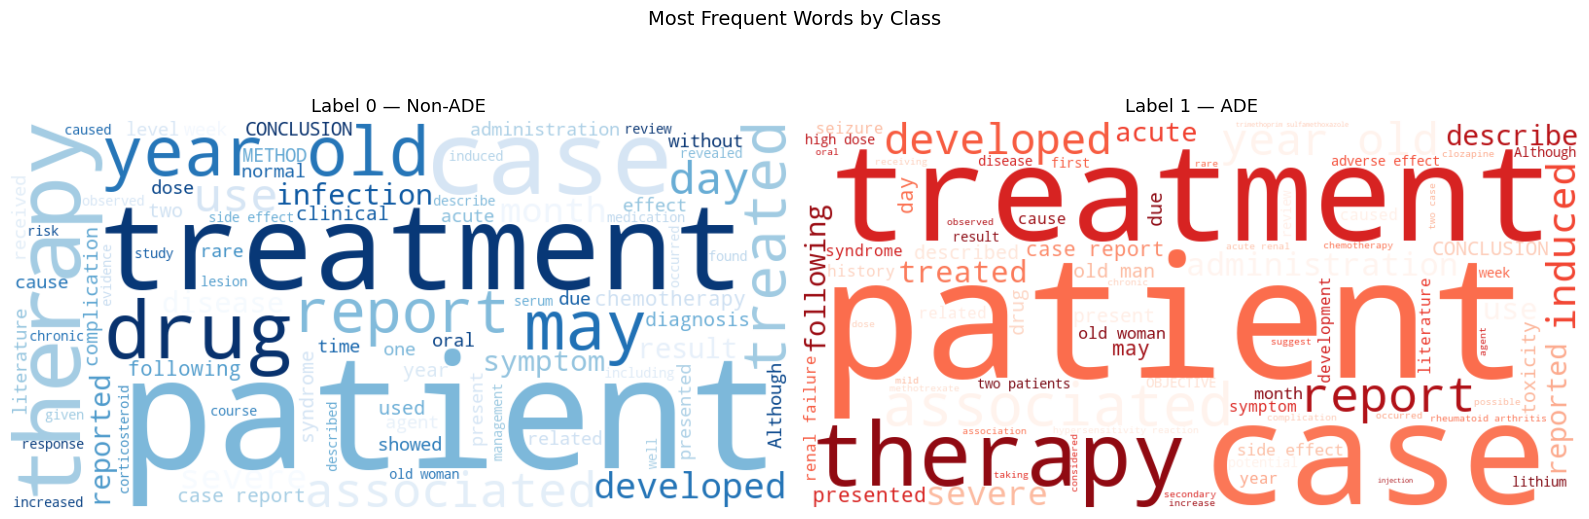

In [7]:
label0_text = " ".join(train[train['label']==0]['text'])
label1_text = " ".join(train[train['label']==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc0 = WordCloud(width=800, height=400, background_color='white',
                colormap='Blues', max_words=80).generate(label0_text)
wc1 = WordCloud(width=800, height=400, background_color='white',
                colormap='Reds', max_words=80).generate(label1_text)

axes[0].imshow(wc0, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Label 0 — Non-ADE', fontsize=13)

axes[1].imshow(wc1, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Label 1 — ADE', fontsize=13)

plt.suptitle('Most Frequent Words by Class', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/wordclouds.png', dpi=150)
plt.show()

## **Sample Sentences by class**
ADE sentences are structurally direct. A drug is named, 
administered or taken, and an adverse outcome is explicitly 
stated in the same sentence. Non-ADE sentences describe clinical 
context, history, procedures, and conditions without establishing 
that causal chain. This structural difference explains why both 
models perform reasonably well and we can see that the signal is real and present 
in the text. The challenge lies in the edge cases where ADE 
language appears without actual causation, or where causation 
is implied rather than stated.

In [8]:
print("=== Sample Non-ADE sentences ===\n")
for text in train[train['label']==0]['text'].sample(5, random_state=42):
    print(f"  {text[:120]}\n")

print("=== Sample ADE sentences ===\n")
for text in train[train['label']==1]['text'].sample(5, random_state=42):
    print(f"  {text[:120]}\n")

=== Sample Non-ADE sentences ===

  Hepatic veno-occlusive disease (VOD) with complete occlusion of liver venules after tandem autologous stem cell transpla

  We report the first case of hairy cell leukemia occurring after cardiac transplantation.

  More than 4 years later, the patient continues to be troubled by persistent paraparesis and chronic pain.

  He was treated with clindamycin, gentamicin and underwent surgical debridement, but succumbed to other complications.

  Essential thrombocythemia is a clonal myeloproliferative disorder that causes thrombocytosis.

=== Sample ADE sentences ===

  Actinomycin D associated hepatic veno-occlusive disease--a report of 2 cases.

  A case of prolonged suxamethonium apnoea successfully terminated by the infusion of a commercial preparation of serumcho

  She was receiving phenytoin sodium 300 mg/day; carbamazepine 200 mg four times daily had been discontinued four days bef

  Bromocriptine-induced schizophrenia.

  Second, we report a ca